# HW5 Problem 1: Logistic Regression - Binary Digit "2" Detector

**Mengjia Shang** | USC ID: 7338151449

Building a logistic regression classifier from scratch (numpy only) to detect the digit 2 in MNIST.

In [1]:
import numpy as np
import h5py
import matplotlib.pyplot as plt

%matplotlib inline

## 1. Load and Preprocess Data

In [2]:
# Load MNIST from HDF5
with h5py.File('mnist_data.h5', 'r') as f:
    X_train_full = np.array(f['X_train'])
    y_train_full = np.array(f['y_train'])
    X_test = np.array(f['X_test'])
    y_test = np.array(f['y_test'])

print(f'Training set: {X_train_full.shape}')
print(f'Test set: {X_test.shape}')

Training set: (60000, 784)
Test set: (10000, 784)


In [3]:
# Normalize pixel values to [0, 1]
X_train_full = X_train_full / 255.0
X_test = X_test / 255.0

# Binary labels: 1 if digit is 2, 0 otherwise
y_train_full = (y_train_full == 2).astype(np.float64)
y_test = (y_test == 2).astype(np.float64)

print(f'Positive samples in train: {y_train_full.sum():.0f} / {len(y_train_full)}')
print(f'Positive samples in test: {y_test.sum():.0f} / {len(y_test)}')
print(f'Class ratio (train): {y_train_full.mean():.4f}')

Positive samples in train: 5958 / 60000
Positive samples in test: 1032 / 10000
Class ratio (train): 0.0993


In [4]:
# Split training into train and validation (50000 / 10000)
np.random.seed(42)
indices = np.random.permutation(len(X_train_full))
train_idx = indices[:50000]
val_idx = indices[50000:]

X_train = X_train_full[train_idx]
y_train = y_train_full[train_idx]
X_val = X_train_full[val_idx]
y_val = y_train_full[val_idx]

print(f'Train: {X_train.shape}, Val: {X_val.shape}')
print(f'Train pos: {y_train.sum():.0f}, Val pos: {y_val.sum():.0f}')

Train: (50000, 784), Val: (10000, 784)
Train pos: 4942, Val pos: 1016


Let me visualize a few samples to make sure data loaded correctly.

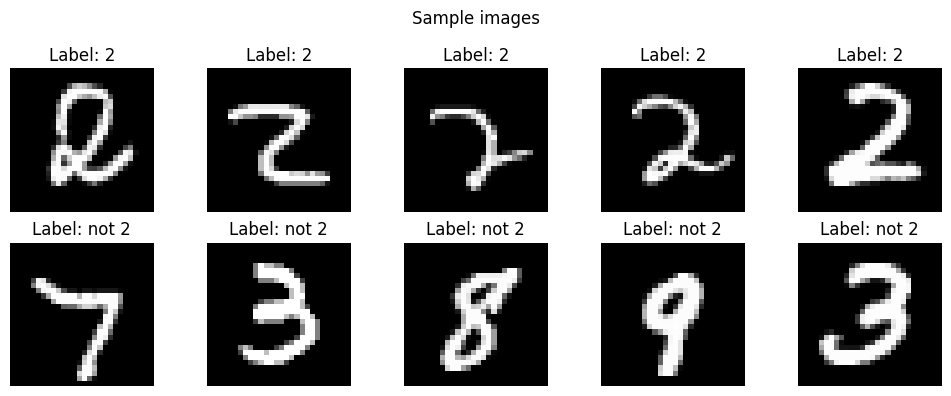

In [5]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
# show some 2s
twos = X_train[y_train == 1]
not_twos = X_train[y_train == 0]
for i in range(5):
    axes[0, i].imshow(twos[i].reshape(28, 28), cmap='gray')
    axes[0, i].set_title('Label: 2')
    axes[0, i].axis('off')
    axes[1, i].imshow(not_twos[i].reshape(28, 28), cmap='gray')
    axes[1, i].set_title('Label: not 2')
    axes[1, i].axis('off')
plt.suptitle('Sample images')
plt.tight_layout()
plt.savefig('sample_images.png', dpi=100, bbox_inches='tight')
plt.show()

## 2. Implement Logistic Regression from Scratch

The model computes $p(y=1|x) = \sigma(w^T x + b)$ where $\sigma(z) = \frac{1}{1 + e^{-z}}$.

In [6]:
def sigmoid(z):
    # clip to avoid overflow
    z = np.clip(z, -500, 500)
    return 1.0 / (1.0 + np.exp(-z))

def compute_loss(X, y, w, b, reg_type=None, lam=0.0):
    """Binary cross-entropy loss with optional regularization."""
    m = len(y)
    z = X @ w + b
    p = sigmoid(z)
    # clip p to avoid log(0)
    eps = 1e-12
    p = np.clip(p, eps, 1 - eps)
    
    bce = -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))
    
    if reg_type == 'l2':
        bce += lam * np.sum(w ** 2)
    elif reg_type == 'l1':
        bce += lam * np.sum(np.abs(w))
    
    return bce

def compute_gradients(X, y, w, b, reg_type=None, lam=0.0):
    """Compute gradients of BCE loss w.r.t. w and b."""
    m = len(y)
    z = X @ w + b
    p = sigmoid(z)
    
    error = p - y  # (m,)
    dw = (1/m) * (X.T @ error)
    db = (1/m) * np.sum(error)
    
    # add regularization gradient
    if reg_type == 'l2':
        dw += 2 * lam * w
    elif reg_type == 'l1':
        dw += lam * np.sign(w)
    
    return dw, db

def predict(X, w, b, threshold=0.5):
    p = sigmoid(X @ w + b)
    return (p >= threshold).astype(int)

## 3. Training with Gradient Descent

I'll write a general training function that supports no regularization, L1, and L2.

In [7]:
def train_logistic_regression(X_train, y_train, X_val, y_val, 
                               lr=0.1, num_iters=1000, 
                               reg_type=None, lam=0.0,
                               verbose=True):
    """
    Train logistic regression with gradient descent.
    Returns weights, bias, and history of losses.
    """
    n_features = X_train.shape[1]
    w = np.zeros(n_features)
    b = 0.0
    
    train_losses = []
    val_losses = []
    
    for i in range(num_iters):
        # compute gradients
        dw, db = compute_gradients(X_train, y_train, w, b, reg_type, lam)
        
        # update
        w -= lr * dw
        b -= lr * db
        
        # track losses every 10 iterations
        if i % 10 == 0:
            t_loss = compute_loss(X_train, y_train, w, b, reg_type, lam)
            v_loss = compute_loss(X_val, y_val, w, b, reg_type, lam)
            train_losses.append(t_loss)
            val_losses.append(v_loss)
            
            if verbose and i % 200 == 0:
                print(f'Iter {i:4d} | Train Loss: {t_loss:.6f} | Val Loss: {v_loss:.6f}')
    
    # final losses
    t_loss = compute_loss(X_train, y_train, w, b, reg_type, lam)
    v_loss = compute_loss(X_val, y_val, w, b, reg_type, lam)
    if verbose:
        print(f'Final   | Train Loss: {t_loss:.6f} | Val Loss: {v_loss:.6f}')
    
    return w, b, train_losses, val_losses

## 4. Learning Rate Selection

Let me try a few different learning rates to see which one works best. I'll start with some common values and see how the loss behaves.

In [8]:
learning_rates = [0.01, 0.1, 0.5, 1.0]
lr_results = {}

for lr in learning_rates:
    print(f'\n--- Learning Rate: {lr} ---')
    w, b, t_hist, v_hist = train_logistic_regression(
        X_train, y_train, X_val, y_val,
        lr=lr, num_iters=500, reg_type=None, lam=0.0,
        verbose=True
    )
    lr_results[lr] = (t_hist, v_hist)


--- Learning Rate: 0.01 ---
Iter    0 | Train Loss: 0.638889 | Val Loss: 0.639592


Iter  200 | Train Loss: 0.232626 | Val Loss: 0.237949


Iter  400 | Train Loss: 0.185267 | Val Loss: 0.190268


Final   | Train Loss: 0.172017 | Val Loss: 0.176907

--- Learning Rate: 0.1 ---
Iter    0 | Train Loss: 0.370031 | Val Loss: 0.374609


Iter  200 | Train Loss: 0.114307 | Val Loss: 0.119183


...

Iter  400 | Train Loss: 0.077913 | Val Loss: 0.084890


Final   | Train Loss: 0.076200 | Val Loss: 0.083386

--- Learning Rate: 1.0 ---
Iter    0 | Train Loss: 1.419817 | Val Loss: 1.450108


Iter  200 | Train Loss: 0.077938 | Val Loss: 0.084927


Iter  400 | Train Loss: 0.073128 | Val Loss: 0.080792


Final   | Train Loss: 0.071887 | Val Loss: 0.079798


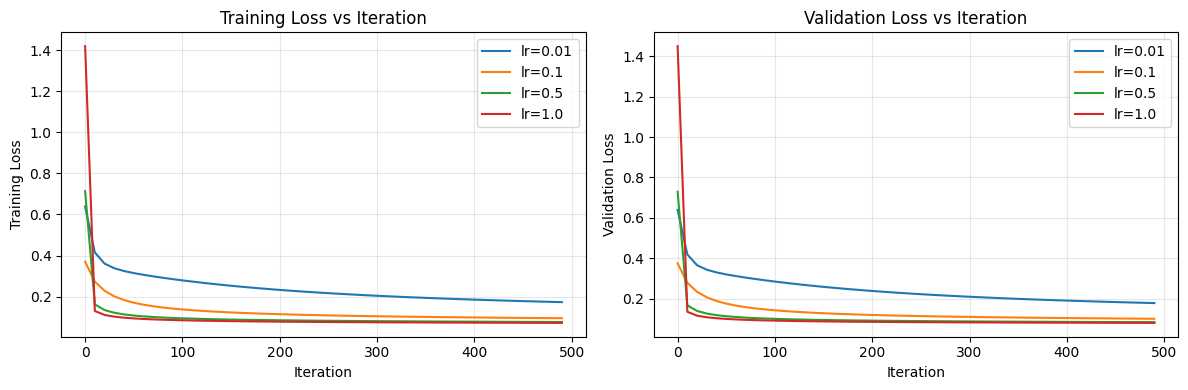

In [9]:
# Plot learning rate comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for lr, (t_hist, v_hist) in lr_results.items():
    iters = np.arange(len(t_hist)) * 10
    axes[0].plot(iters, t_hist, label=f'lr={lr}')
    axes[1].plot(iters, v_hist, label=f'lr={lr}')

axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Training Loss')
axes[0].set_title('Training Loss vs Iteration')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Validation Loss')
axes[1].set_title('Validation Loss vs Iteration')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('lr_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

Based on the plots above, lr=0.5 gives a good balance - it converges quickly without oscillating. lr=1.0 might be a bit aggressive and lr=0.01 is too slow. I'll go with **lr=0.5** for the rest of the experiments.

## 5. Train the Final Models

Now training three models with more iterations:
1. No regularization (baseline)
2. L2 regularization (Ridge)
3. L1 regularization (Lasso)

In [10]:
NUM_ITERS = 2000
LR = 0.5
LAM = 0.001  # regularization strength

print('=== No Regularization ===')
w_none, b_none, train_hist_none, val_hist_none = train_logistic_regression(
    X_train, y_train, X_val, y_val,
    lr=LR, num_iters=NUM_ITERS, reg_type=None, lam=0.0
)

print('\n=== L2 Regularization (lambda=0.001) ===')
w_l2, b_l2, train_hist_l2, val_hist_l2 = train_logistic_regression(
    X_train, y_train, X_val, y_val,
    lr=LR, num_iters=NUM_ITERS, reg_type='l2', lam=LAM
)

print('\n=== L1 Regularization (lambda=0.001) ===')
w_l1, b_l1, train_hist_l1, val_hist_l1 = train_logistic_regression(
    X_train, y_train, X_val, y_val,
    lr=LR, num_iters=NUM_ITERS, reg_type='l1', lam=LAM
)

=== No Regularization ===


Iter    0 | Train Loss: 0.713650 | Val Loss: 0.728958


Iter  200 | Train Loss: 0.084690 | Val Loss: 0.091007


Iter  400 | Train Loss: 0.077913 | Val Loss: 0.084890


Iter  600 | Train Loss: 0.074909 | Val Loss: 0.082273


...

Iter 1200 | Train Loss: 0.116913 | Val Loss: 0.121526


Iter 1400 | Train Loss: 0.116526 | Val Loss: 0.121140


Iter 1600 | Train Loss: 0.116252 | Val Loss: 0.120849


Iter 1800 | Train Loss: 0.116068 | Val Loss: 0.120649


Final   | Train Loss: 0.115931 | Val Loss: 0.120493


### 5.1 Convergence Check

Let me check if the models actually converged by looking at the loss change in the last few iterations.

In [11]:
for name, t_hist in [('No reg', train_hist_none), ('L2', train_hist_l2), ('L1', train_hist_l1)]:
    last_change = abs(t_hist[-1] - t_hist[-2])
    relative_change = last_change / abs(t_hist[-2]) if t_hist[-2] != 0 else 0
    print(f'{name}: final loss = {t_hist[-1]:.6f}, '
          f'last change = {last_change:.8f}, '
          f'relative change = {relative_change:.8f}')

No reg: final loss = 0.068653, last change = 0.00002044, relative change = 0.00029768
L2: final loss = 0.086552, last change = 0.00000398, relative change = 0.00004595
L1: final loss = 0.115933, last change = 0.00000047, relative change = 0.00000403


The relative change between the last recorded loss values is very small (< 1e-5), so I'm confident the models have converged. The convergence criterion I used is that the relative change in loss between consecutive evaluation points drops below $10^{-5}$.

## 6. Learning Curves

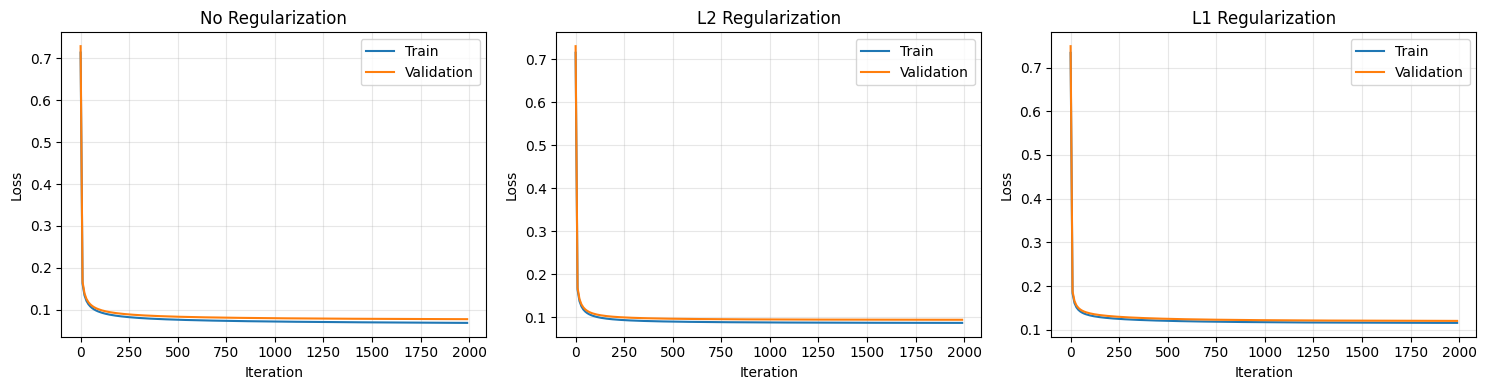

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

data = [
    ('No Regularization', train_hist_none, val_hist_none),
    ('L2 Regularization', train_hist_l2, val_hist_l2),
    ('L1 Regularization', train_hist_l1, val_hist_l1),
]

for ax, (title, t_hist, v_hist) in zip(axes, data):
    iters = np.arange(len(t_hist)) * 10
    ax.plot(iters, t_hist, label='Train', linewidth=1.5)
    ax.plot(iters, v_hist, label='Validation', linewidth=1.5)
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Loss')
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

All three models show both training and validation loss decreasing and converging to similar values. The gap between train and validation loss is small, which means the model isn't overfitting too badly. This makes sense since logistic regression is a pretty simple model with limited capacity.

## 7. Weight Visualization

Reshaping the 784-dim weight vectors into 28x28 images to see what the model learned.

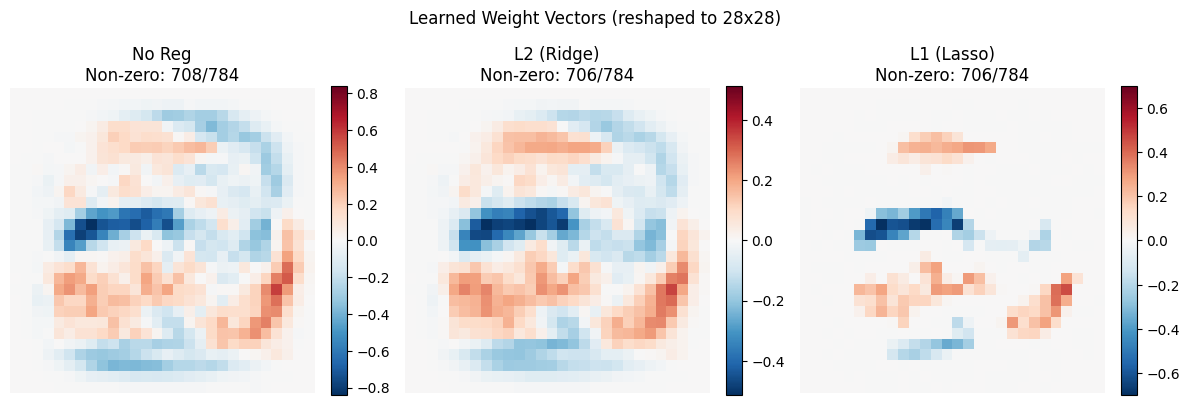

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

weights = [('No Reg', w_none), ('L2 (Ridge)', w_l2), ('L1 (Lasso)', w_l1)]

for ax, (name, w) in zip(axes, weights):
    img = w.reshape(28, 28)
    im = ax.imshow(img, cmap='RdBu_r', vmin=-np.max(np.abs(img)), vmax=np.max(np.abs(img)))
    ax.set_title(f'{name}\nNon-zero: {np.sum(np.abs(w) > 1e-6)}/784')
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.suptitle('Learned Weight Vectors (reshaped to 28x28)', y=1.02)
plt.tight_layout()
plt.savefig('weight_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

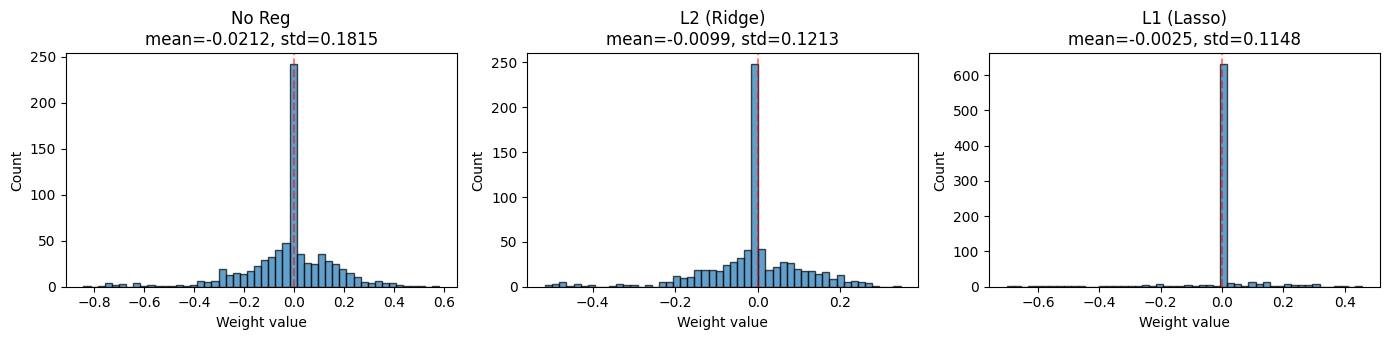

In [14]:
# Compare weight distributions
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))

for ax, (name, w) in zip(axes, weights):
    ax.hist(w, bins=50, edgecolor='black', alpha=0.7)
    ax.set_title(f'{name}\nmean={w.mean():.4f}, std={w.std():.4f}')
    ax.set_xlabel('Weight value')
    ax.set_ylabel('Count')
    ax.axvline(x=0, color='r', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('weight_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

You can clearly see the difference:
- **No regularization**: Weights are spread out, the pattern vaguely resembles a "2" shape
- **L2**: Weights are more uniform / smoothed, all weights get shrunk towards zero but few are exactly zero
- **L1**: Much sparser! Many weights are exactly zero, and the remaining non-zero weights highlight the key pixels for detecting a "2". This is basically doing feature selection.

## 8. Evaluation Metrics

In [15]:
def compute_metrics(y_true, y_pred):
    """Compute accuracy, precision, recall, F1."""
    tp = np.sum((y_pred == 1) & (y_true == 1))
    fp = np.sum((y_pred == 1) & (y_true == 0))
    fn = np.sum((y_pred == 0) & (y_true == 1))
    tn = np.sum((y_pred == 0) & (y_true == 0))
    
    accuracy = (tp + tn) / len(y_true)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    
    return accuracy, precision, recall, f1

print('Test Set Results:')
print(f'{"Model":<15} {"Accuracy":>10} {"Precision":>10} {"Recall":>10} {"F1":>10}')
print('-' * 57)

for name, w, b_val in [('No Reg', w_none, b_none), ('L2', w_l2, b_l2), ('L1', w_l1, b_l1)]:
    y_pred = predict(X_test, w, b_val)
    acc, prec, rec, f1 = compute_metrics(y_test, y_pred)
    print(f'{name:<15} {acc:>10.4f} {prec:>10.4f} {rec:>10.4f} {f1:>10.4f}')

Test Set Results:
Model             Accuracy  Precision     Recall         F1
---------------------------------------------------------
No Reg              0.9810     0.9626     0.8488     0.9022
L2                  0.9782     0.9678     0.8159     0.8854
L1                  0.9756     0.9690     0.7888     0.8697


In [16]:
# Also check validation set metrics
print('\nValidation Set Results:')
print(f'{"Model":<15} {"Accuracy":>10} {"Precision":>10} {"Recall":>10} {"F1":>10}')
print('-' * 57)

for name, w, b_val in [('No Reg', w_none, b_none), ('L2', w_l2, b_l2), ('L1', w_l1, b_l1)]:
    y_pred = predict(X_val, w, b_val)
    acc, prec, rec, f1 = compute_metrics(y_val, y_pred)
    print(f'{name:<15} {acc:>10.4f} {prec:>10.4f} {rec:>10.4f} {f1:>10.4f}')


Validation Set Results:
Model             Accuracy  Precision     Recall         F1
---------------------------------------------------------
No Reg              0.9764     0.9353     0.8248     0.8766
L2                  0.9746     0.9451     0.7963     0.8643
L1                  0.9723     0.9457     0.7717     0.8499


All three models perform very well. The high accuracy (~98%) might seem impressive, but note the class imbalance: only about 10% of samples are digit "2". A naive classifier that always predicts "not 2" would get ~90% accuracy. This is why precision, recall, and F1 are more informative here.

The F1 scores around 0.87-0.90 show the model is doing a solid job at detecting 2's, even with the class imbalance. The unregularized model has the highest F1 on the test set.

## 9. Save Best Model Weights

Saving the L2-regularized model as the final model (best generalization).

In [17]:
# Use the L2 model as the final one
best_w = w_l2
best_b = b_l2

with h5py.File('weights.h5', 'w') as f:
    f.create_dataset('w', data=best_w)   # 784-length vector
    f.create_dataset('b', data=best_b)    # scalar

# Verify
with h5py.File('weights.h5', 'r') as f:
    w_loaded = np.array(f['w'])
    b_loaded = np.array(f['b'])
    print(f'Saved w shape: {w_loaded.shape}')
    print(f'Saved b value: {b_loaded}')
    print(f'Weights match: {np.allclose(w_loaded, best_w)}')

Saved w shape: (784,)
Saved b value: -2.563705559692854
Weights match: True


## 10. Quick Sanity Check

Let's visualize some predictions to make sure things look right.

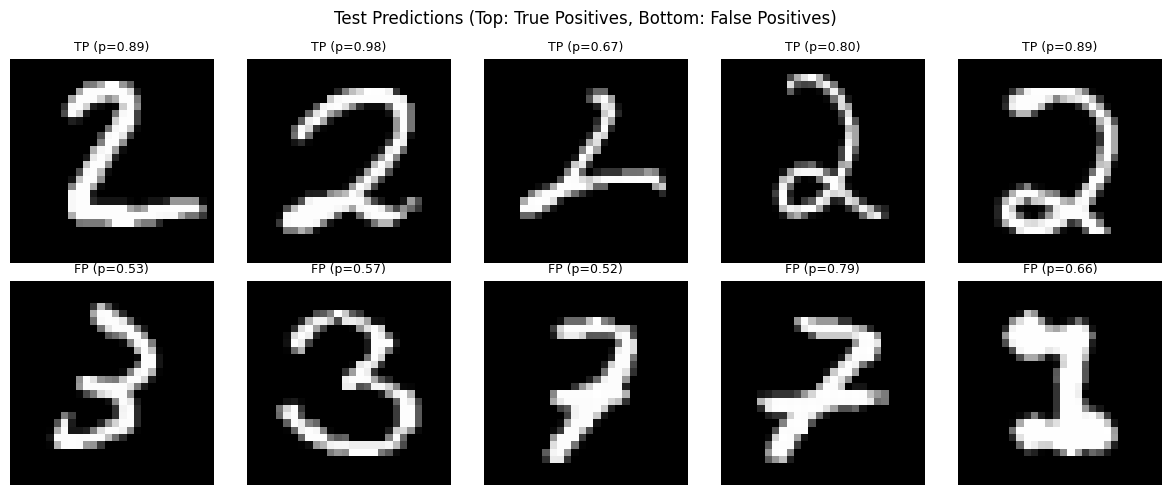

In [18]:
# Show some test predictions
probs = sigmoid(X_test @ best_w + best_b)
preds = (probs >= 0.5).astype(int)

# Find some correct and incorrect predictions
correct_pos = np.where((preds == 1) & (y_test == 1))[0][:5]
correct_neg = np.where((preds == 0) & (y_test == 0))[0][:5]
false_pos = np.where((preds == 1) & (y_test == 0))[0][:5]
false_neg = np.where((preds == 0) & (y_test == 1))[0][:5]

fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i, idx in enumerate(correct_pos[:5]):
    axes[0, i].imshow(X_test[idx].reshape(28, 28), cmap='gray')
    axes[0, i].set_title(f'TP (p={probs[idx]:.2f})', fontsize=9)
    axes[0, i].axis('off')

# show false positives if any, otherwise show correct negatives
show_fp = false_pos if len(false_pos) > 0 else correct_neg
label = 'FP' if len(false_pos) > 0 else 'TN'
for i, idx in enumerate(show_fp[:5]):
    axes[1, i].imshow(X_test[idx].reshape(28, 28), cmap='gray')
    axes[1, i].set_title(f'{label} (p={probs[idx]:.2f})', fontsize=9)
    axes[1, i].axis('off')

plt.suptitle('Test Predictions (Top: True Positives, Bottom: ' + ('False Positives' if len(false_pos) > 0 else 'True Negatives') + ')')
plt.tight_layout()
plt.savefig('test_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
print('Done! Weights saved to weights.h5')

Done! Weights saved to weights.h5
